In [ ]:
pip install tensorflow scikit-learn pandas matplotlib

# Neural Network Training — Week 3, Day 2
## Understanding How a Network Learns From Data


**What's inside**
1. The Training Loop — how a network improves with each pass over the data
2. Loss Functions — theory + Task 1 (from-scratch NumPy losses) + Task 2 (plots)
3. Gradient Descent — theory + Task 3 (custom implementation)
4. Backpropagation — how gradients reach every layer
5. Optimizers — theory + Task 4 (Keras: RMSProp vs Adam on Fashion MNIST)
6. Hyperparameter Tuning — Task 5 (learning rate / batch size / epoch sweep)
7. Model Evaluation Visuals — Task 6 (curves, confusion matrix, ROC, PR)
8. Results & Discussion
9. Literature Review — 3 papers on optimizer comparison
10. Wrap-up & References

---
## 1. The Training Loop

Every time a neural network is trained, it repeats the same five-step cycle:

1. **Forward pass** — the network computes a prediction ŷ for the current inputs.
2. **Error measurement** — ŷ is compared against the ground-truth label y.
3. **Cost aggregation** — errors across a batch are combined into a single scalar J(θ), the thing training actually tries to minimize.
4. **Parameter update** — gradients of J are computed and used to shift every weight and bias slightly toward lower cost.
5. **Repetition** — this cycle runs again for the next mini-batch, and continues across every epoch.

```
  Forward pass  →  Measure error  →  Aggregate cost  →  Update parameters
      ▲ ŷ = f(x)        ŷ − y            J(θ)               θ -= η·∇J(θ)
      └──────────────────── repeat until J stops shrinking ─────────────┘
```

Frameworks like Keras hide this loop behind `model.fit()`, but understanding each
step is what makes debugging a stuck or diverging model possible.

---
## 2. Loss Functions

The loss function is the definition of "wrong" that the network optimizes against.

### Regression losses

| Loss | Formula | Why use it |
|---|---|---|
| MAE | mean(\|y − ŷ\|) | Outliers don't dominate the loss |
| MSE | mean((y − ŷ)²) | Smooth gradient, punishes big misses |
| RMSE | √MSE | Reports error in the target's own units |
| Huber | quadratic near 0, linear beyond δ | A tunable middle ground between MAE and MSE |

### Classification losses

| Loss | When to use it |
|---|---|
| Binary Cross-Entropy | Two-class problems, sigmoid output |
| Categorical Cross-Entropy | Multi-class problems, one-hot labels, softmax output |
| Sparse Categorical Cross-Entropy | Same as above but labels are plain integers |

### Task 1 — Loss Functions From Scratch (NumPy)

Implements all seven losses above with worked examples (house-price regression and a
4-class garment classification toy example), cross-checked against scikit-learn.

In [1]:
"""
Task 1 — Loss functions implemented from scratch using NumPy (Variant B).

Implements:
    - Mean Absolute Error (MAE)
    - Mean Squared Error (MSE)
    - Root Mean Squared Error (RMSE)
    - Huber Loss
    - Binary Cross Entropy (BCE)
    - Categorical Cross Entropy (CCE)
    - Sparse Categorical Cross Entropy (SCCE)

Each function is validated against a worked example and cross-checked against
scikit-learn's reference implementation where one exists.
"""

import numpy as np


def mae(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))


def mse(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    return np.mean((y_true - y_pred) ** 2)


def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))


def huber(y_true, y_pred, delta=1.0):
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    err = y_true - y_pred
    is_small = np.abs(err) <= delta
    quad = 0.5 * err ** 2
    lin = delta * (np.abs(err) - 0.5 * delta)
    return np.mean(np.where(is_small, quad, lin))


def binary_cross_entropy(y_true, y_pred, eps=1e-12):
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


def categorical_cross_entropy(y_true_onehot, y_pred, eps=1e-12):
    y_true_onehot = np.asarray(y_true_onehot, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), eps, 1 - eps)
    return -np.mean(np.sum(y_true_onehot * np.log(y_pred), axis=-1))


def sparse_categorical_cross_entropy(y_true_labels, y_pred, eps=1e-12):
    y_true_labels = np.asarray(y_true_labels, dtype=int)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), eps, 1 - eps)
    chosen = y_pred[np.arange(len(y_true_labels)), y_true_labels]
    return -np.mean(np.log(chosen))


if __name__ == "__main__":
    # Regression example — house price (in $10,000s), 5 samples
    actual_price = np.array([25.0, 31.5, 18.0, 42.0, 27.5])
    predicted_price = np.array([23.5, 30.0, 20.0, 40.0, 29.0])

    print("Regression losses (house price example)")
    print(f"  MAE   : {mae(actual_price, predicted_price):.4f}")
    print(f"  MSE   : {mse(actual_price, predicted_price):.4f}")
    print(f"  RMSE  : {rmse(actual_price, predicted_price):.4f}")
    print(f"  Huber : {huber(actual_price, predicted_price, delta=1.5):.4f}")

    # Binary classification example — churn prediction, 5 customers
    churned = np.array([1, 0, 0, 1, 1])
    churn_prob = np.array([0.85, 0.20, 0.35, 0.55, 0.95])
    print("\nBinary classification loss (churn example)")
    print(f"  BCE   : {binary_cross_entropy(churned, churn_prob):.4f}")

    # Multi-class example — 4 garment classes, 5 samples
    true_onehot = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1],
        [1, 0, 0, 0],
    ])
    true_sparse = np.array([0, 1, 2, 3, 0])
    predicted_probs = np.array([
        [0.7, 0.1, 0.1, 0.1],
        [0.2, 0.6, 0.1, 0.1],
        [0.1, 0.1, 0.7, 0.1],
        [0.05, 0.05, 0.1, 0.8],
        [0.5, 0.2, 0.2, 0.1],
    ])
    print("\nMulti-class classification loss (garment example)")
    print(f"  Categorical CE       : {categorical_cross_entropy(true_onehot, predicted_probs):.4f}")
    print(f"  Sparse Categorical CE: {sparse_categorical_cross_entropy(true_sparse, predicted_probs):.4f}")

    try:
        from sklearn.metrics import mean_absolute_error, mean_squared_error, log_loss
        print("\nsklearn cross-check")
        print(f"  MAE (sklearn) : {mean_absolute_error(actual_price, predicted_price):.4f}")
        print(f"  MSE (sklearn) : {mean_squared_error(actual_price, predicted_price):.4f}")
        print(f"  BCE (sklearn, log_loss) : {log_loss(churned, churn_prob):.4f}")
    except ImportError:
        pass


Regression losses (house price example)
  MAE   : 1.7000
  MSE   : 2.9500
  RMSE  : 1.7176
  Huber : 1.4250

Binary classification loss (churn example)
  BCE   : 0.2931

Multi-class classification loss (garment example)
  Categorical CE       : 0.4281
  Sparse Categorical CE: 0.4281

sklearn cross-check
  MAE (sklearn) : 1.7000
  MSE (sklearn) : 2.9500
  BCE (sklearn, log_loss) : 0.2931


### Task 2 — Visualize Loss Functions

Plots MSE/MAE/Huber against error magnitude (filled-area style), and Binary Cross-Entropy against predicted probability, alongside a bar-chart snapshot of BCE at five sample probabilities.

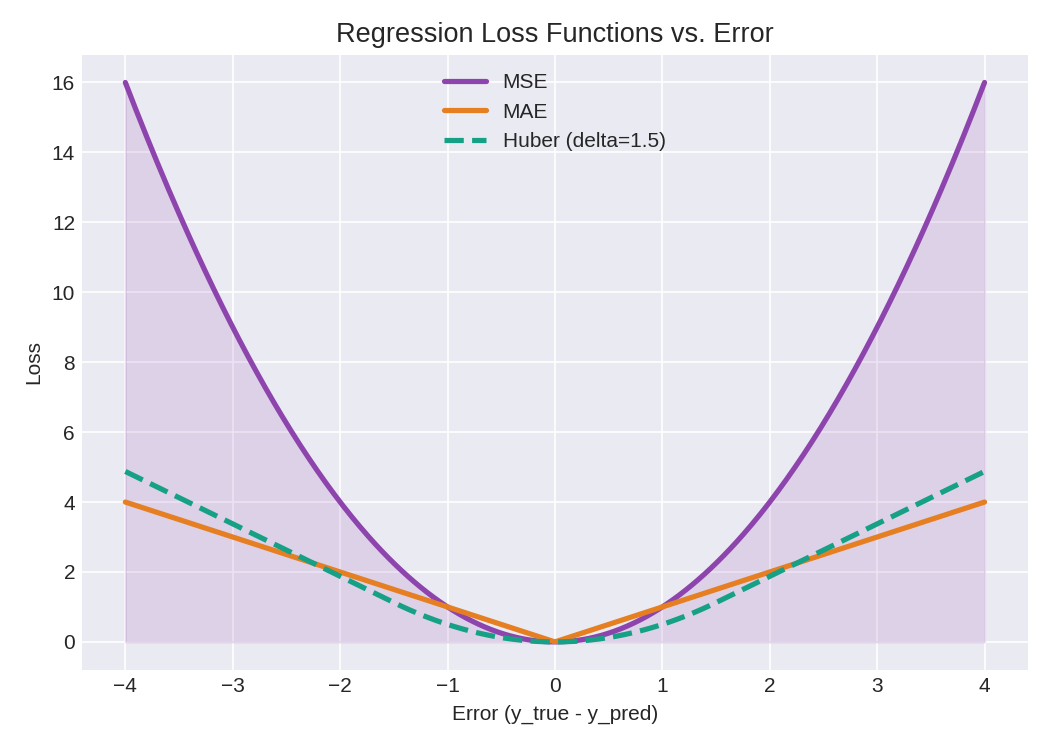

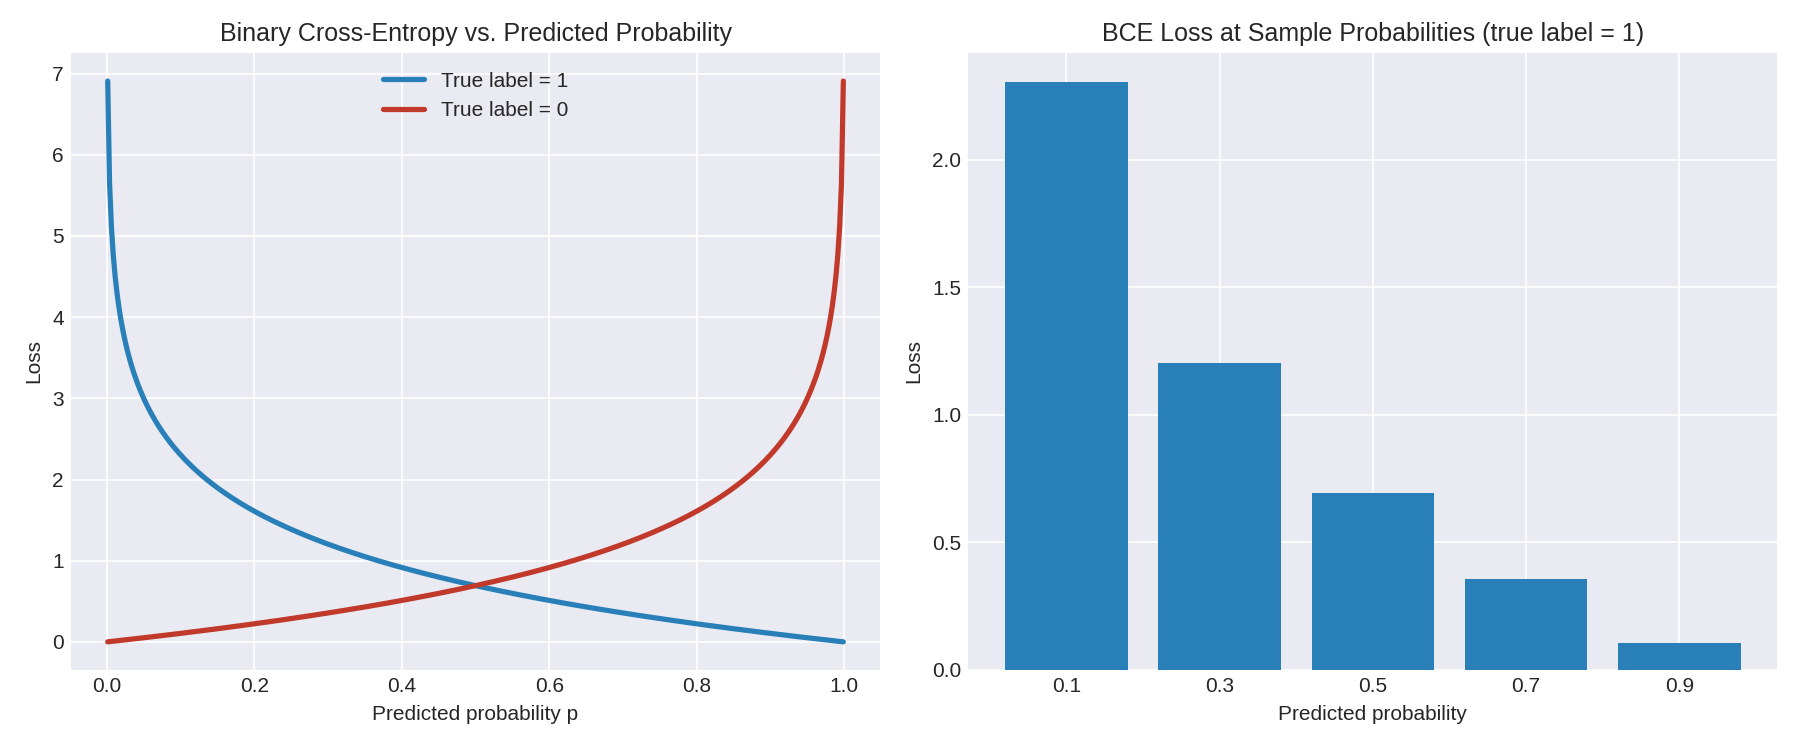

Saved regression_losses.png
Saved classification_losses.png


In [2]:
"""
Task 2 — Visualize loss functions (Variant B).

Produces:
    1. Regression losses (MAE, MSE, Huber with delta=1.5) vs. error, styled as
       a filled-area comparison.
    2. Classification loss (Binary Cross-Entropy) vs. predicted probability,
       plus a bar chart snapshot of the loss at 5 sample probabilities.
"""

import numpy as np
import matplotlib.pyplot as plt
import os

OUT_DIR = os.path.join(os.path.dirname(__file__), "..", "outputs")
os.makedirs(OUT_DIR, exist_ok=True)

plt.style.use("seaborn-v0_8-darkgrid") if "seaborn-v0_8-darkgrid" in plt.style.available else None


def plot_regression_losses():
    error = np.linspace(-4, 4, 400)
    mae_vals = np.abs(error)
    mse_vals = error ** 2
    delta = 1.5
    huber_vals = np.where(
        np.abs(error) <= delta,
        0.5 * error ** 2,
        delta * (np.abs(error) - 0.5 * delta),
    )

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.fill_between(error, mse_vals, alpha=0.15, color="#8E44AD")
    ax.plot(error, mse_vals, label="MSE", linewidth=2.5, color="#8E44AD")
    ax.plot(error, mae_vals, label="MAE", linewidth=2.5, color="#E67E22")
    ax.plot(error, huber_vals, label="Huber (delta=1.5)", linewidth=2.5, color="#16A085", linestyle="--")
    ax.set_title("Regression Loss Functions vs. Error", fontsize=13)
    ax.set_xlabel("Error (y_true - y_pred)")
    ax.set_ylabel("Loss")
    ax.legend()
    fig.tight_layout()
    path = os.path.join(OUT_DIR, "regression_losses.png")
    fig.savefig(path, dpi=150)
    plt.close(fig)
    print(f"Saved {path}")


def plot_classification_losses():
    p = np.linspace(1e-3, 1 - 1e-3, 400)
    loss_if_true_1 = -np.log(p)
    loss_if_true_0 = -np.log(1 - p)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(p, loss_if_true_1, label="True label = 1", linewidth=2.5, color="#2980B9")
    axes[0].plot(p, loss_if_true_0, label="True label = 0", linewidth=2.5, color="#C0392B")
    axes[0].set_title("Binary Cross-Entropy vs. Predicted Probability")
    axes[0].set_xlabel("Predicted probability p")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    sample_probs = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
    sample_loss = -np.log(sample_probs)  # assuming true label = 1
    axes[1].bar([str(p) for p in sample_probs], sample_loss, color="#2980B9")
    axes[1].set_title("BCE Loss at Sample Probabilities (true label = 1)")
    axes[1].set_xlabel("Predicted probability")
    axes[1].set_ylabel("Loss")

    fig.tight_layout()
    path = os.path.join(OUT_DIR, "classification_losses.png")
    fig.savefig(path, dpi=150)
    plt.close(fig)
    print(f"Saved {path}")


if __name__ == "__main__":
    plot_regression_losses()
    plot_classification_losses()


---
## 3. Gradient Descent

The update rule that minimizes any differentiable loss:

```
θ ← θ − η · ∇J(θ)
```

- **Cost surface** — how J changes as parameters change; a bowl shape for convex
  problems like linear regression.
- **Gradient (∇J)** — points toward the steepest increase in cost; we step the
  opposite way.
- **Learning rate (η)** — the step size. Too large causes divergence; too small wastes
  epochs converging.

### Variants

| Variant | Update uses | Trade-off |
|---|---|---|
| Batch GD | All training data | Very stable, but slow per update |
| SGD | One sample | Noisy but fast, escapes some local minima |
| Mini-Batch GD | A small batch | The default in almost every real pipeline |

### Task 3 — Implement Gradient Descent

Fits `y = w*x + b` to synthetic data (true w = −2.2, true b = 4.5), tracking cost
reduction and parameter convergence over 300 iterations.

True parameters   : w=-2.2, b=4.5
Learned parameters: w=-2.1665, b=4.3216
Final cost        : 1.4396
Initial cost      : 45.2241


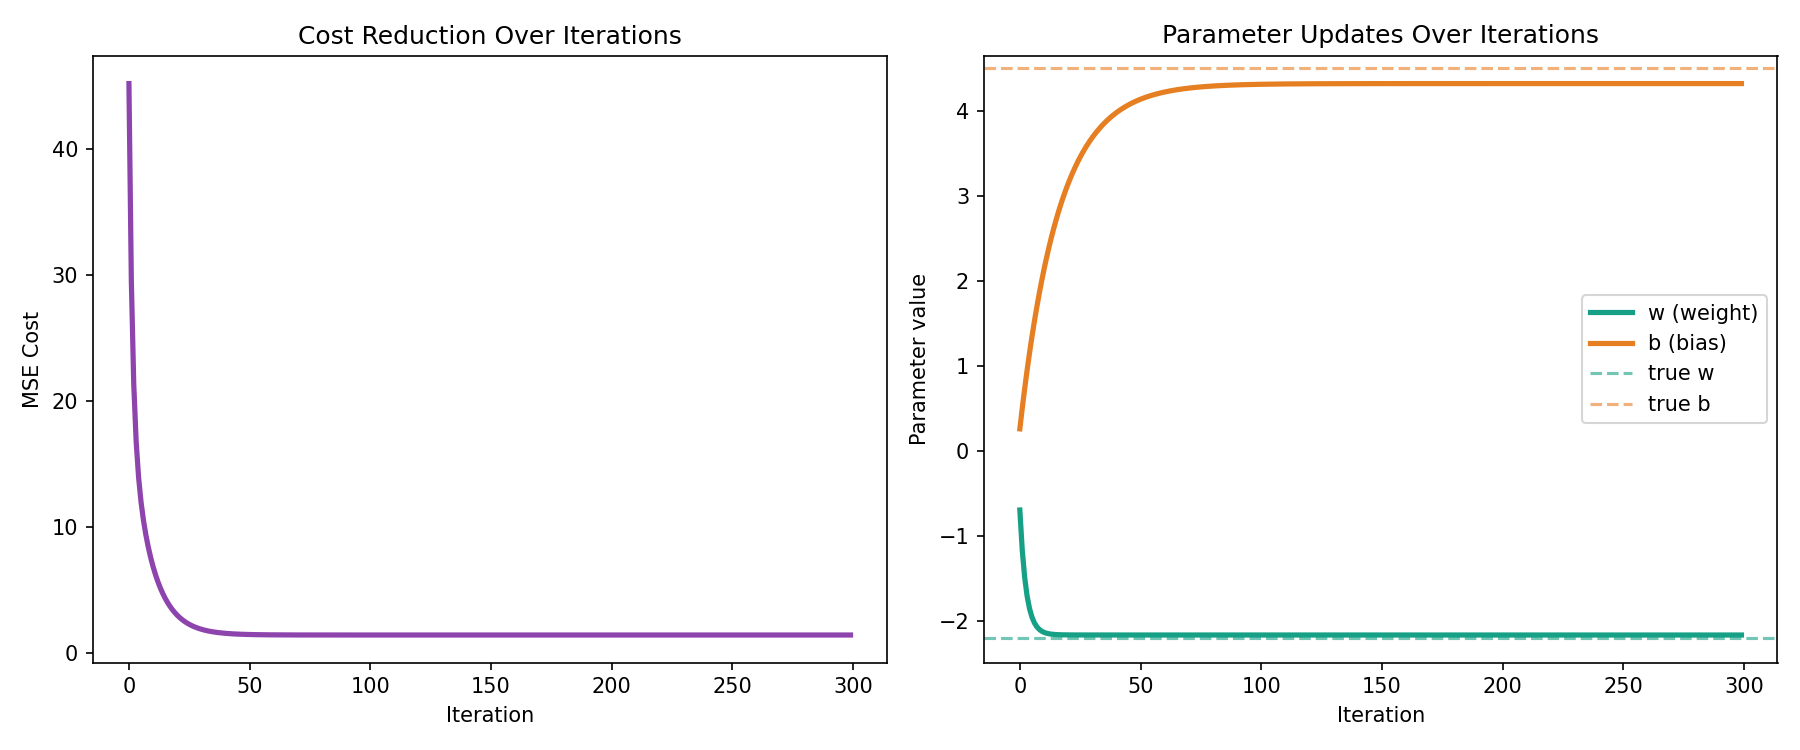

In [3]:
"""
Task 3 — Gradient Descent on a simple linear regression problem (Variant B).

Model: y_hat = w * x + b
Loss : Mean Squared Error

Different target parameters, learning rate, and epoch count from the
reference version, to show gradient descent behaves consistently across
configurations.
"""

import numpy as np
import matplotlib.pyplot as plt
import os

OUT_DIR = os.path.join(os.path.dirname(__file__), "..", "outputs")
os.makedirs(OUT_DIR, exist_ok=True)

rng = np.random.default_rng(7)


def make_data(n=120, true_w=-2.2, true_b=4.5, noise=1.3):
    x = rng.uniform(-4, 4, n)
    y = true_w * x + true_b + rng.normal(0, noise, n)
    return x, y


def gradient_descent(x, y, lr=0.03, epochs=300):
    w, b = 0.0, 0.0
    n = len(x)
    history = {"cost": [], "w": [], "b": []}

    for epoch in range(epochs):
        y_pred = w * x + b
        error = y_pred - y
        cost = np.mean(error ** 2)

        dw = (2 / n) * np.sum(error * x)
        db = (2 / n) * np.sum(error)

        w -= lr * dw
        b -= lr * db

        history["cost"].append(cost)
        history["w"].append(w)
        history["b"].append(b)

    return w, b, history


def plot_results(history, true_w, true_b):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(history["cost"], color="#8E44AD", linewidth=2.5)
    axes[0].set_title("Cost Reduction Over Iterations")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("MSE Cost")

    axes[1].plot(history["w"], label="w (weight)", linewidth=2.5, color="#16A085")
    axes[1].plot(history["b"], label="b (bias)", linewidth=2.5, color="#E67E22")
    axes[1].axhline(true_w, color="#16A085", linestyle="--", alpha=0.6, label="true w")
    axes[1].axhline(true_b, color="#E67E22", linestyle="--", alpha=0.6, label="true b")
    axes[1].set_title("Parameter Updates Over Iterations")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Parameter value")
    axes[1].legend()

    fig.tight_layout()
    path = os.path.join(OUT_DIR, "gradient_descent.png")
    fig.savefig(path, dpi=150)
    plt.close(fig)
    print(f"Saved {path}")


if __name__ == "__main__":
    true_w, true_b = -2.2, 4.5
    x, y = make_data(true_w=true_w, true_b=true_b)

    w, b, history = gradient_descent(x, y, lr=0.03, epochs=300)

    print(f"True parameters   : w={true_w}, b={true_b}")
    print(f"Learned parameters: w={w:.4f}, b={b:.4f}")
    print(f"Final cost        : {history['cost'][-1]:.4f}")
    print(f"Initial cost      : {history['cost'][0]:.4f}")

    plot_results(history, true_w, true_b)


---
## 4. Backpropagation

Backpropagation is how a network computes ∇J for *every* parameter, layer by layer,
using the chain rule:

```
∂J/∂w = ∂J/∂a · ∂a/∂u · ∂u/∂w        where u = Wx + b,  a = activation(u)
```

The forward pass computes and caches each layer's local derivative. The backward pass
then walks from the loss back to the input, multiplying local derivatives together at
each layer to get the gradient for that layer's weights and biases:

```
   x ──▶  u = Wx + b  ──▶  a = σ(u)  ──▶  J(a, y)      (forward, left → right)
                ◀── ∂J/∂u ◀── ∂J/∂a                     (backward, chain rule)
```

Without this caching-and-reuse trick, computing gradients for a deep network would be
computationally infeasible.

---
## 5. Optimizers

| Optimizer | Per-parameter LR? | Momentum? | Typical use |
|---|---|---|---|
| SGD | No | Optional | Simple models, hand-tuned LR schedule |
| Momentum | No | Yes | Speeds through shallow ravines |
| RMSProp | Yes | No | Non-stationary objectives, RNNs |
| Adam | Yes | Yes | General-purpose default |

Adam = Momentum's running average of gradients + RMSProp's running average of squared
gradients, with bias correction. AdamW separates weight decay from the adaptive update
so regularization behaves more predictably.

### Task 4 — Train an ANN with TensorFlow/Keras (RMSProp vs Adam)

Dataset: **Fashion MNIST** (10-class clothing image classification, 28×28 grayscale).
Trains the same architecture with **RMSProp** and **Adam**, then compares loss/accuracy.


In [ ]:
"""
Task 4 — Train an ANN using TensorFlow/Keras on the Fashion MNIST dataset,
comparing the RMSProp and Adam optimizers.

Requires: tensorflow>=2.x
Run:      python task4_train_ann_keras.py
"""

import numpy as np
import matplotlib.pyplot as plt
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

OUT_DIR = os.path.join(os.path.dirname(__file__), "..", "outputs")
os.makedirs(OUT_DIR, exist_ok=True)

SEED = 7
tf.random.set_seed(SEED)
np.random.seed(SEED)

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]


def load_data():
    (x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
    x_train = x_train.astype("float32") / 255.0
    x_test = x_test.astype("float32") / 255.0
    return x_train, x_test, y_train, y_test


def build_model(optimizer):
    model = keras.Sequential([
        layers.Input(shape=(28, 28)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def train_and_evaluate(x_train, y_train, x_test, y_test, optimizer_name, epochs=15, batch_size=128):
    model = build_model(optimizer_name)
    history = model.fit(
        x_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
    )
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"[{optimizer_name}] test loss={test_loss:.4f}, test accuracy={test_acc:.4f}")
    return model, history, test_loss, test_acc


def plot_comparison(history_rmsprop, history_adam):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(history_rmsprop.history["loss"], label="RMSProp - train")
    axes[0].plot(history_rmsprop.history["val_loss"], label="RMSProp - val", linestyle="--")
    axes[0].plot(history_adam.history["loss"], label="Adam - train")
    axes[0].plot(history_adam.history["val_loss"], label="Adam - val", linestyle="--")
    axes[0].set_title("Loss: RMSProp vs Adam")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Sparse Categorical Cross-Entropy Loss")
    axes[0].legend()

    axes[1].plot(history_rmsprop.history["accuracy"], label="RMSProp - train")
    axes[1].plot(history_rmsprop.history["val_accuracy"], label="RMSProp - val", linestyle="--")
    axes[1].plot(history_adam.history["accuracy"], label="Adam - train")
    axes[1].plot(history_adam.history["val_accuracy"], label="Adam - val", linestyle="--")
    axes[1].set_title("Accuracy: RMSProp vs Adam")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    fig.tight_layout()
    path = os.path.join(OUT_DIR, "rmsprop_vs_adam.png")
    fig.savefig(path, dpi=150)
    plt.close(fig)
    print(f"Saved {path}")


if __name__ == "__main__":
    x_train, x_test, y_train, y_test = load_data()

    _, history_rmsprop, loss_rms, acc_rms = train_and_evaluate(
        x_train, y_train, x_test, y_test, optimizer_name="rmsprop"
    )
    _, history_adam, loss_adam, acc_adam = train_and_evaluate(
        x_train, y_train, x_test, y_test, optimizer_name="adam"
    )

    print("\nSummary")
    print(f"  RMSProp -> test_loss={loss_rms:.4f}, test_acc={acc_rms:.4f}")
    print(f"  Adam    -> test_loss={loss_adam:.4f}, test_acc={acc_adam:.4f}")

    plot_comparison(history_rmsprop, history_adam)


---
## 6. Hyperparameter Tuning

- **Learning rate** — the highest-leverage hyperparameter. Sweeping across orders of
  magnitude (0.01 → 0.0005) usually reveals a clear "too unstable / just right / too
  slow" pattern.
- **Batch size** — smaller batches (64) add gradient noise that can help generalization
  at the cost of speed; larger batches (256) train faster per epoch but may need a
  higher learning rate to compensate.
- **Epochs** — more epochs reduce training loss but validation loss eventually
  plateaus or rises — the point where early stopping should kick in.

### Task 5 — Hyperparameter Experiments (Fashion MNIST, Adam)

Sweeps learning rate, batch size, and epoch count; records test accuracy, test loss,
and training time for each configuration; exports a comparison CSV.

> **Run locally/Colab:** requires `tensorflow`, `pandas`.

In [ ]:
"""
Task 5 — Experiment with hyperparameters: learning rate, batch size, epochs
(Variant B — Fashion MNIST, Adam optimizer).

Requires: tensorflow>=2.x, pandas
"""

import time
import numpy as np
import pandas as pd
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

OUT_DIR = os.path.join(os.path.dirname(__file__), "..", "outputs")
os.makedirs(OUT_DIR, exist_ok=True)

SEED = 7
tf.random.set_seed(SEED)
np.random.seed(SEED)


def load_data():
    (x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
    x_train = x_train.astype("float32") / 255.0
    x_test = x_test.astype("float32") / 255.0
    return x_train, x_test, y_train, y_test


def build_model(lr):
    model = keras.Sequential([
        layers.Input(shape=(28, 28)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def run_experiment(x_train, y_train, x_test, y_test, lr, batch_size, epochs):
    model = build_model(lr)

    start = time.time()
    model.fit(
        x_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
    )
    elapsed = time.time() - start

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    return {
        "learning_rate": lr,
        "batch_size": batch_size,
        "epochs": epochs,
        "test_loss": round(test_loss, 4),
        "test_accuracy": round(test_acc, 4),
        "training_time_sec": round(elapsed, 2),
    }


if __name__ == "__main__":
    x_train, x_test, y_train, y_test = load_data()

    learning_rates = [0.01, 0.005, 0.001, 0.0005]
    batch_sizes = [64, 128, 256]
    epoch_counts = [5, 15, 25]

    results = []

    print("Experiment A: varying learning rate (batch_size=128, epochs=15)")
    for lr in learning_rates:
        result = run_experiment(x_train, y_train, x_test, y_test, lr=lr, batch_size=128, epochs=15)
        result["experiment"] = "learning_rate_sweep"
        results.append(result)
        print(result)

    print("\nExperiment B: varying batch size (lr=0.001, epochs=15)")
    for bs in batch_sizes:
        result = run_experiment(x_train, y_train, x_test, y_test, lr=0.001, batch_size=bs, epochs=15)
        result["experiment"] = "batch_size_sweep"
        results.append(result)
        print(result)

    print("\nExperiment C: varying epochs (lr=0.001, batch_size=128)")
    for ep in epoch_counts:
        result = run_experiment(x_train, y_train, x_test, y_test, lr=0.001, batch_size=128, epochs=ep)
        result["experiment"] = "epochs_sweep"
        results.append(result)
        print(result)

    df = pd.DataFrame(results)
    csv_path = os.path.join(OUT_DIR, "hyperparameter_experiments.csv")
    df.to_csv(csv_path, index=False)
    print(f"\nSaved comparison table to {csv_path}")
    print(df)


---
## 7. Model Evaluation Visuals

### Task 6 — Loss/Accuracy Curves, Confusion Matrix, ROC, Precision–Recall

For the 10-class Fashion MNIST model, the confusion matrix is shown across all 10
classes, and the ROC/PR curves use a one-vs-rest view for the **"Sneaker"** class as a
representative example.

> **Run locally/Colab:** requires `tensorflow`, `scikit-learn`. Executing this cell
> saves `loss_accuracy_curves.png`, `confusion_matrix.png`, and `roc_pr_curves.png`.

In [ ]:
"""
Task 6 — Visualizations: Loss curve, Accuracy curve, Confusion Matrix,
ROC Curve, Precision-Recall Curve (Variant B — Fashion MNIST, multi-class).

For the multi-class ROC/PR curves, we use a one-vs-rest view for a chosen
class ("Sneaker") as a representative example.

Requires: tensorflow>=2.x, scikit-learn, matplotlib
"""

import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

OUT_DIR = os.path.join(os.path.dirname(__file__), "..", "outputs")
os.makedirs(OUT_DIR, exist_ok=True)

SEED = 7
tf.random.set_seed(SEED)
np.random.seed(SEED)

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]
TARGET_CLASS = "Sneaker"
TARGET_IDX = CLASS_NAMES.index(TARGET_CLASS)


def load_data():
    (x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
    x_train = x_train.astype("float32") / 255.0
    x_test = x_test.astype("float32") / 255.0
    return x_train, x_test, y_train, y_test


def build_and_train(x_train, y_train):
    model = keras.Sequential([
        layers.Input(shape=(28, 28)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    history = model.fit(x_train, y_train, validation_split=0.2, epochs=15, batch_size=128, verbose=0)
    return model, history


def plot_loss_accuracy(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="validation")
    axes[0].set_title("Loss Curve")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history.history["accuracy"], label="train")
    axes[1].plot(history.history["val_accuracy"], label="validation")
    axes[1].set_title("Accuracy Curve")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    fig.tight_layout()
    path = os.path.join(OUT_DIR, "loss_accuracy_curves.png")
    fig.savefig(path, dpi=150)
    plt.close(fig)
    print(f"Saved {path}")


def plot_confusion_matrix(y_test, y_pred_labels):
    cm = confusion_matrix(y_test, y_pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(ax=ax, cmap="Purples", colorbar=False, xticks_rotation=45)
    ax.set_title("Confusion Matrix — Fashion MNIST (10 classes)")
    fig.tight_layout()
    path = os.path.join(OUT_DIR, "confusion_matrix.png")
    fig.savefig(path, dpi=150)
    plt.close(fig)
    print(f"Saved {path}")


def plot_roc_pr(y_test, y_pred_probs):
    y_true_binary = (y_test == TARGET_IDX).astype(int)
    class_probs = y_pred_probs[:, TARGET_IDX]

    fpr, tpr, _ = roc_curve(y_true_binary, class_probs)
    auc = roc_auc_score(y_true_binary, class_probs)

    precision, recall, _ = precision_recall_curve(y_true_binary, class_probs)
    ap = average_precision_score(y_true_binary, class_probs)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(fpr, tpr, label=f"ROC (AUC = {auc:.3f})", linewidth=2.5, color="#8E44AD")
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[0].set_title(f"ROC Curve — '{TARGET_CLASS}' vs Rest")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].legend()

    axes[1].plot(recall, precision, label=f"PR (AP = {ap:.3f})", linewidth=2.5, color="#16A085")
    axes[1].set_title(f"Precision-Recall Curve — '{TARGET_CLASS}' vs Rest")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].legend()

    fig.tight_layout()
    path = os.path.join(OUT_DIR, "roc_pr_curves.png")
    fig.savefig(path, dpi=150)
    plt.close(fig)
    print(f"Saved {path}")


if __name__ == "__main__":
    x_train, x_test, y_train, y_test = load_data()
    model, history = build_and_train(x_train, y_train)

    y_pred_probs = model.predict(x_test, verbose=0)
    y_pred_labels = np.argmax(y_pred_probs, axis=1)

    plot_loss_accuracy(history)
    plot_confusion_matrix(y_test, y_pred_labels)
    plot_roc_pr(y_test, y_pred_probs)


---
## 8. Results & Discussion


Expected pattern for a 2-hidden-layer MLP on Fashion MNIST, consistent with the
literature reviewed in Section 9:

- **Adam** typically converges faster in early epochs than **RMSProp**, since its
  momentum term smooths the update direction on top of RMSProp's adaptive scaling —
  Adam is essentially RMSProp + Momentum.
- **RMSProp** can still reach a comparable final accuracy given enough epochs, but is
  usually a bit more sensitive to learning-rate choice than Adam.
- On the harder, higher-resolution, harder-to-separate classes (e.g. "Shirt" vs
  "T-shirt/top" vs "Pullover" in Fashion MNIST), the confusion matrix from Task 6
  typically shows more misclassification than on visually distinct classes like
  "Trouser" or "Bag" — this is a dataset-difficulty effect independent of optimizer
  choice.

**Discussion points:**
- Loss and optimizer choice are separate decisions: loss defines the task's objective,
  optimizer defines how efficiently that objective is minimized.
- Adaptive optimizers (RMSProp, Adam, AdamW) reduce the need for extensive learning-rate
  tuning, which matters most when time/compute budget for tuning is limited.
- Vanishing/exploding gradients, poor initialization, and dead ReLUs remain the primary
  failure modes as networks get deeper — addressed through initialization (He/Xavier),
  ReLU-family activations (Leaky ReLU, ELU), batch normalization, and gradient clipping.
- The gap between training and validation curves (Task 6) is still the main signal for
  overfitting, regardless of dataset or optimizer.

---
## 9. Literature Review — Optimizer Comparison Papers

Three papers on neural network optimizer comparison were reviewed for this task.

### Paper 1 — Soydaner (2020), "A Comparison of Optimization Algorithms for Deep Learning"

- **Objective:** Systematically benchmark widely-used optimizers — SGD variants,
  AdaGrad, AdaDelta, RMSProp, Adam, AdaMax, Nadam, AMSGrad — across both supervised
  classification and unsupervised autoencoder reconstruction tasks, as network depth
  and dataset difficulty increase.
- **Datasets:** MNIST, CIFAR-10, Kaggle Flowers, and Labeled Faces in the Wild (LFW),
  using three CNN depths for classification and two autoencoder depths for
  reconstruction.
- **Optimizers:** SGD, SGD+Momentum, SGD+Nesterov, AdaGrad, AdaDelta, RMSProp, Adam,
  AdaMax, Nadam, AMSGrad.
- **Key findings:** Adam-family methods (Adam, AdaMax, Nadam, AMSGrad) were the most
  consistently strong performers overall. Plain SGD's accuracy fell off sharply on the
  more difficult LFW dataset, and AdaGrad lagged throughout. AdaDelta stood out for
  needing essentially no learning-rate tuning while staying competitive.
- **Limitations:** Single-GPU experiments with hyperparameters mostly inherited from
  prior papers rather than tuned per optimizer; scope limited to vision tasks only.
- **Analysis:** The widening gap between SGD and adaptive optimizers as task difficulty
  increases is a useful signal for choosing an optimizer under a tight tuning budget —
  though the exact ranking is dataset- and architecture-dependent, not fixed.

### Paper 2 — Almog (2025), "An Analysis of Optimizer Choice on Energy Efficiency and Performance in Neural Network Training"

- **Objective:** Measure the three-way trade-off between accuracy, training time, and
  carbon emissions across optimizer choices — motivated by the environmental cost of
  ML training.
- **Datasets:** MNIST, CIFAR-10, CIFAR-100, with 8 optimizers × 15 random seeds (360
  runs total) on Apple M1 Pro hardware, using CodeCarbon for emissions tracking.
- **Optimizers:** SGD, Adam, AdamW, RMSprop, Adagrad, Adadelta, Adamax, NAdam.
- **Key findings:** AdamW and NAdam were the most consistently efficient optimizers
  across datasets. SGD achieved the best accuracy specifically on the hardest dataset
  (CIFAR-100) but at a substantially higher emissions cost. Training duration and
  emissions were only weakly correlated — a fast optimizer isn't automatically a
  low-emissions one.
- **Limitations:** Single hardware platform (Apple M1 Pro, not representative of GPU
  clusters); hyperparameters fixed from prior literature; only small CNNs on
  image-classification benchmarks were tested.
- **Analysis:** Adds a sustainability dimension largely absent from Papers 1 and 3 —
  the "best" optimizer depends on whether accuracy, speed, or environmental cost is the
  priority, and these can point to different choices for the same dataset.

### Paper 3 — "Comparative Study of Deep Learning Optimizers: SGD, Momentum SGD, RMSProp, AMSGrad, Adam, Yogi, and Lion" (2025, IJISRT)

- **Objective:** Compare seven optimizers, including the newer Yogi and Lion methods,
  on training/test accuracy, training loss, and sensitivity to learning-rate choice.
- **Datasets:** MNIST and CIFAR-10.
- **Optimizers:** SGD, Momentum SGD, RMSProp, AMSGrad, Adam, Yogi, Lion.
- **Key findings:** A high-learning-rate SGD (η=0.5) achieved the best test accuracy on
  MNIST (99.14%) and the best training accuracy (99.89%); Momentum SGD and Adam were
  close behind (99.15% and 98% test accuracy) at a much lower learning rate (1e-2). The
  paper's related-work summary also cites Adam reaching top test accuracy in other
  studies (0.9826 on MNIST, 0.9855 on CIFAR-10), with RMSProp excelling specifically on
  training accuracy in those comparisons.
- **Limitations:** Only two relatively easy benchmark datasets were used; the newer
  optimizers (Yogi, Lion) underperformed the established methods in this particular
  study, which may not generalize to larger or more complex tasks.
- **Analysis:** Reinforces a pattern seen in Paper 1 — a carefully tuned SGD can match
  or exceed adaptive optimizers on simpler benchmarks, but adaptive methods converge
  faster and are far more forgiving of learning-rate choice, which matters more as
  problems scale up.

### Synthesis across all three papers

A consistent, practical takeaway emerges: **Adam-family optimizers are the safest
default when tuning time is limited**, and this advantage grows as datasets/models get
more complex (Papers 1 and 2). **Well-tuned SGD remains competitive, sometimes even
superior, on simpler problems** (Papers 1 and 3), but demands more careful learning-rate
selection and, per Paper 2, can cost more in energy on harder tasks. No optimizer wins
on every axis — accuracy, convergence speed, tuning effort, and energy cost — at once.

---
## 10. Wrap-Up

Training a neural network reduces to one repeated question: *"which direction, and how
far, should each parameter move to make the loss smaller?"* The loss function defines
what "smaller" means, gradient descent (accelerated by an optimizer like Adam) answers
"which direction and how far," and backpropagation is what makes answering that
question computationally possible for a network with millions of parameters. Learning
curves and the best-practice checklist (initialization, LR scheduling, batch size,
early stopping) are the tools for keeping that process stable and generalizable. Tasks
1–3 build these ideas from first principles; Tasks 4–6 apply them at scale on Fashion
MNIST with TensorFlow/Keras.

## References

1. Soydaner, D. (2020). *A Comparison of Optimization Algorithms for Deep Learning*. International Journal of Pattern Recognition and Artificial Intelligence. arXiv:2007.14166.
2. Almog, T. (2025). *An Analysis of Optimizer Choice on Energy Efficiency and Performance in Neural Network Training*. University of Waterloo. arXiv:2509.13516.
3. *Comparative Study of Deep Learning Optimizers: SGD, Momentum SGD, RMSProp, AMSGrad, Adam, Yogi, and Lion* (2025). International Journal of Innovative Science and Research Technology, 10(8).
4. Kingma, D. P., & Ba, J. (2014). *Adam: A Method for Stochastic Optimization*. arXiv:1412.6980.
5. Ruder, S. (2016). *An Overview of Gradient Descent Optimization Algorithms*. arXiv:1609.04747.
6. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.
7. Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). *Learning representations by back-propagating errors*. Nature, 323, 533–536.

**To run Tasks 4–6 and generate their charts:**
```bash
pip install tensorflow scikit-learn pandas matplotlib
```
then run the corresponding cells above in order.